In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
import numpy as np
import yaml
import pickle
from itertools import product, cycle
import os, sys
from tqdm.notebook import tqdm
from scipy import stats
import scikit_posthocs as sp

from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[1]))

*Analysis to perform*

1. Summary table of mean +- std of performances Dataset/Method/Metric
2. Analysis binned by total missing ratio;
3. Analysis binned by MNAR percentage; 

In [2]:
# load simulation results

# !!!! Need to change output fiel to current timestamp

simulation_path = "../output/simulation_results02_03_2026.pkl"

with open(simulation_path, 'rb') as input_file:
    simulation_results = pickle.load(input_file)

In [3]:
# Load simulation configuration

with open("../config/simulation_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# conf is a tuple (dataset_id,props,mf_proportions,mnar_proportions, seed)

configs = list(product(
    cfg['dataset_ids'],
    cfg['md_param_grid']['props'],
    cfg['md_param_grid']['mf_proportions'],
    cfg['md_param_grid']['mnar_proportions'],
    range(cfg['n_runs'])
    ))

In [4]:
TESTED_METHODS = [
        #'mige_no_proj',
        'mige_proj',
        #'mige_no_proj_mutual',
        #'mige_proj_mutual',
        'mica',
        'kpod',
        'mghm',
        'mcnm',
        'sc_knn',
        'sc_mi',
        'km_knn',
        'km_si'
    ]


TESTED_METHOD_STATS = [
    #'mige_no_proj',
        'mige_proj',
        #'mige_no_proj_mutual',
        #'mige_proj_mutual',
        'mica',
        'kpod',
        #'mghm',
        #'mcnm',
        'sc_knn',
        'sc_mi',
        'km_knn',
        'km_si'
]

In [5]:
# configs of dataset = dataset_id
# dataset_id = configs[0][0]
# key_subset = {k: v for k, v in d.items() if k[0] == X} this is for dictionaries
# conf_subset = [conf for conf in configs if conf[0] == dataset_id]

cfg['dataset_ids']

[33, 45, 17, 15, 174, 544]

In [6]:
def read_pickle(path):
    with open(path, 'rb') as input_file:
        return pickle.load(input_file)

In [7]:
# simulation results is a dictionary structured as such:
# simulation_results[conf][metric_type] metric_type in {external_metrics, internal_metrics}
# conf is a tuple (dataset_id,props,mf_proportions,mnar_proportions, seed)
# subset dictionary for first element subset = {k: v for k, v in d.items() if k[0] == X}

In [8]:
# tested external metrics 
external_metrics = list(simulation_results[configs[0]]['external_metrics']['mige_no_proj'])
# tested internal metrics 
internal_metrics = list(simulation_results[configs[0]]['internal_metrics']['mige_no_proj'])
# tested methods
methods = list(simulation_results[configs[0]]['internal_metrics'])

In [9]:
def safe_get(v, key1, key2):
    """
    This function is a safe get with double key because some are not list but single np.nan
    """
    try:
        return v[key1][key2]
    except:
        return np.nan

def spaghetti_dataframe_(df, metric_name):
    """
    This function is specific to pivot a dataframe into long format
    """
    df_long = (
        df.T
        .assign(metric=metric_name)
        .set_index("metric", append=True)
        .stack()
    )
    return df_long

In [10]:
def combine_dataset(results_df, metrics):
    """
    From aggregated result datasets with the form: 
    {metric: {dataset: {method: <value>}}}
    """
    long_dfs = {
    metric: spaghetti_dataframe_(
            df = pd.DataFrame.from_dict(results_df[metric]),
            metric_name = metric
        )
    for metric in metrics
    }
    combined = pd.DataFrame(pd.concat([df for df in long_dfs.values()]))
    combined.index = combined.index.set_names(['dataset','metric','method'])
    combined = combined.rename({0: "value"}, axis = 'columns') 
    combined = combined.unstack(level = -1)
    return combined

# External metrics aggregates

In [11]:
# build dictionaries to store:
# - results (lists for each of the 10 runs)
# - means and stds (single value)
# dictionary form {metric: {dataset: {method: <value>}}}

external_metrics_results = {met:{d:{m:[] for m in methods} for d in cfg['dataset_ids']} for met in external_metrics}
external_metrics_means = {met:{d:{m:np.nan for m in methods} for d in cfg['dataset_ids']} for met in external_metrics}
external_metrics_stds = {met:{d:{m:np.nan for m in methods} for d in cfg['dataset_ids']} for met in external_metrics}

for k1,v1 in simulation_results.items():
    dataset_id = k1[0]
    # collect results
    for metric in external_metrics:
        for method in methods:
            #res = v1['external_metrics'][method][metric]
            res = safe_get(v1['external_metrics'],method,metric)
            external_metrics_results[metric][dataset_id][method].append(res)

# calculate means and standard deviations
for metric,v1 in external_metrics_results.items():
    for dataset_id, v2 in v1.items():
        for method,v3 in v2.items():
            external_metrics_means[metric][dataset_id][method] = np.mean(v3)
            external_metrics_stds[metric][dataset_id][method] = np.std(v3)

In [12]:
combined_external_means = combine_dataset(external_metrics_means,external_metrics)
combined_external_stds = combine_dataset(external_metrics_stds,external_metrics)
combined_external_means.head(5)

value                                                 \
method         mige_no_proj mige_proj mige_no_proj_mutual mige_proj_mutual   
dataset metric                                                               
15      ami        0.758106  0.758576            0.000058        -0.000065   
        ari        0.854217  0.854312           -0.001280        -0.000146   
        cs         0.758572  0.759106            0.047617         0.048844   
        vm         0.758380  0.758850            0.002697         0.002502   
17      ami        0.691453  0.693467            0.298829         0.279819   

                                                                            \
method              mica      kpod      mcnm      mghm    sc_knn     sc_mi   
dataset metric                                                               
15      ami     0.726967  0.483840       NaN  0.619954  0.586804  0.592394   
        ari     0.829677  0.531245       NaN  0.699463  0.673868  0.676952   
        cs      0.732657  0.537054       NaN  0.610515  0.616349  0.622770   
        vm      0.727279  0.484503       NaN  0.620378  0.587296  0.592880   
17      ami     0.457682  0.125200  0.511701  0.520766  0.498188  0.527763   

                                                            
method            km_knn     km_si cca_spectral cca_kmeans  
dataset metric                                              
15      ami     0.711883  0.728391     0.565245   0.747541  
        ari     0.816393  0.830840     0.633178   0.846468  
        cs      0.719007  0.734017     0.604710   0.752830  
        vm      0.712213  0.728701     0.565770   0.747829  
17      ami     0.455544  0.458674     0.536739   0.464005

## Ranks for external metrics

In [13]:
combined_external_means['value'][TESTED_METHODS].rank(axis = 'columns', ascending = False)

method          mige_proj  mica  kpod  mghm  mcnm  sc_knn  sc_mi  km_knn  \
dataset metric                                                             
15      ami           1.0   3.0   8.0   5.0   NaN     7.0    6.0     4.0   
        ari           1.0   3.0   8.0   5.0   NaN     7.0    6.0     4.0   
        cs            1.0   3.0   8.0   7.0   NaN     6.0    5.0     4.0   
        vm            1.0   3.0   8.0   5.0   NaN     7.0    6.0     4.0   
17      ami           1.0   7.0   9.0   3.0   4.0     5.0    2.0     8.0   
        ari           1.0   8.0   9.0   2.0   4.0     5.0    3.0     7.0   
        cs            1.0   7.0   9.0   3.0   5.0     4.0    2.0     8.0   
        vm            1.0   7.0   9.0   3.0   4.0     5.0    2.0     8.0   
33      ami           1.0   6.0   7.0   NaN   NaN     3.0    2.0     5.0   
        ari           1.0   5.0   7.0   NaN   NaN     3.0    2.0     6.0   
        cs            1.0   6.0   7.0   NaN   NaN     3.0    2.0     5.0   
        vm            1.0   6.0   7.0   NaN   NaN     3.0    2.0     5.0   
45      ami           1.0   6.0   7.0   NaN   NaN     2.0    3.0     5.0   
        ari           1.0   5.0   7.0   NaN   NaN     2.0    3.0     6.0   
        cs            1.0   5.0   7.0   NaN   NaN     2.0    3.0     6.0   
        vm            1.0   6.0   7.0   NaN   NaN     2.0    3.0     5.0   
174     ami           1.0   5.0   7.0   NaN   NaN     2.0    6.0     3.0   
        ari           1.0   4.0   5.0   NaN   NaN     6.0    7.0     2.0   
        cs            1.0   5.0   7.0   NaN   NaN     2.0    6.0     3.0   
        vm            1.0   5.0   7.0   NaN   NaN     2.0    6.0     3.0   
544     ami           5.0   2.0   4.0   NaN   NaN     6.0    7.0     3.0   
        ari           6.0   1.0   5.0   NaN   NaN     4.0    7.0     2.0   
        cs            5.0   1.0   4.0   NaN   NaN     6.0    7.0     3.0   
        vm            5.0   2.0   4.0   NaN   NaN     6.0    7.0     3.0   

method          km_si  
dataset metric         
15      ami       2.0  
        ari       2.0  
        cs        2.0  
        vm        2.0  
17      ami       6.0  
        ari       6.0  
        cs        6.0  
        vm        6.0  
33      ami       4.0  
        ari       4.0  
        cs        4.0  
        vm        4.0  
45      ami       4.0  
        ari       4.0  
        cs        4.0  
        vm        4.0  
174     ami       4.0  
        ari       3.0  
        cs        4.0  
        vm        4.0  
544     ami       1.0  
        ari       3.0  
        cs        2.0  
        vm        1.0

In [14]:
# Calculate average rank for each method
combined_external_means['value'][TESTED_METHODS].rank(axis = 'columns', ascending = False).mean(axis=0)

method
mige_proj    1.708333
mica         4.625000
kpod         6.958333
mghm         4.125000
mcnm         4.250000
sc_knn       4.166667
sc_mi        4.375000
km_knn       4.666667
km_si        3.583333
dtype: float64

In [15]:
combined_external_means['value'][TESTED_METHODS].to_csv("../output/analysis/combined_external_means.csv")
combined_external_stds['value'][TESTED_METHODS].to_csv("../output/analysis/combined_external_stds.csv")
combined_external_means['value'][TESTED_METHODS].rank(axis = 'columns', ascending = False).to_csv("../output/analysis/combined_external_ranks.csv")

In [16]:
combined_external_means['value'][TESTED_METHODS].T

dataset         15                                      17             \
metric          ami       ari        cs        vm       ami       ari   
method                                                                  
mige_proj  0.758576  0.854312  0.759106  0.758850  0.693467  0.777672   
mica       0.726967  0.829677  0.732657  0.727279  0.457682  0.483824   
kpod       0.483840  0.531245  0.537054  0.484503  0.125200  0.085383   
mghm       0.619954  0.699463  0.610515  0.620378  0.520766  0.580403   
mcnm            NaN       NaN       NaN       NaN  0.511701  0.572151   
sc_knn     0.586804  0.673868  0.616349  0.587296  0.498188  0.518625   
sc_mi      0.592394  0.676952  0.622770  0.592880  0.527763  0.574830   
km_knn     0.711883  0.816393  0.719007  0.712213  0.455544  0.484803   
km_si      0.728391  0.830840  0.734017  0.728701  0.458674  0.485196   

dataset                             33             ...       45             \
metric           cs        vm       ami       ari  ...        cs        vm   
method                                             ...                       
mige_proj  0.710206  0.693885  0.862455  0.829060  ...  0.135536  0.148488   
mica       0.511349  0.458482  0.141577  0.084947  ...  0.047450  0.047855   
kpod       0.264363  0.127034  0.040347  0.012067  ...  0.024327  0.024466   
mghm       0.558455  0.521459       NaN       NaN  ...       NaN       NaN   
mcnm       0.550458  0.512415       NaN       NaN  ...       NaN       NaN   
sc_knn     0.550989  0.498923  0.772181  0.633626  ...  0.107306  0.118409   
sc_mi      0.569416  0.528440  0.795285  0.669003  ...  0.102984  0.113611   
km_knn     0.508080  0.456346  0.147975  0.080568  ...  0.046245  0.048417   
km_si      0.512137  0.459473  0.184704  0.121793  ...  0.053685  0.055993   

dataset         174                                     544            \
metric          ami       ari        cs        vm       ami       ari   
method                                                                  
mige_proj  0.223226  0.150228  0.204694  0.226452  0.277945  0.144131   
mica       0.062188  0.114542  0.066160  0.067654  0.380045  0.242323   
kpod      -0.001014  0.006819  0.016875  0.007024  0.313930  0.169336   
mghm            NaN       NaN       NaN       NaN       NaN       NaN   
mcnm            NaN       NaN       NaN       NaN       NaN       NaN   
sc_knn     0.104467 -0.005613  0.122925  0.110341  0.238977  0.195676   
sc_mi      0.016199 -0.035671  0.063738  0.024928  0.183536  0.136478   
km_knn     0.065068  0.122645  0.069024  0.070421  0.374782  0.240924   
km_si      0.064399  0.120605  0.068371  0.069849  0.380664  0.238647   

dataset                        
metric           cs        vm  
method                         
mige_proj  0.304706  0.281402  
mica       0.392070  0.382859  
kpod       0.347470  0.317309  
mghm            NaN       NaN  
mcnm            NaN       NaN  
sc_knn     0.248174  0.242416  
sc_mi      0.189391  0.187173  
km_knn     0.384347  0.377594  
km_si      0.392001  0.383468  

[9 rows x 24 columns]

# Statistical tests

We run friedman test per dataset 

- each dataset provides a Friedman test, as it has 120 runs

In [21]:
dataset_ids = [k for k in external_metrics_results['ari'].keys()]
dataset_ids

[33, 45, 17, 15, 174, 544]

In [22]:
TESTED_METHOD_STATS

['mige_proj', 'mica', 'kpod', 'sc_knn', 'sc_mi', 'km_knn', 'km_si']

In [23]:
statistical_test_results = {}
statistical_test_results['ari'] = {}
statistical_test_results['ami'] = {}

statistical_test_results_posthoc = {}
statistical_test_results_posthoc['ari'] = {}
statistical_test_results_posthoc['ami'] = {}

In [24]:
for metric in ['ari','ami']:
    for dataset in dataset_ids:

        temp = external_metrics_results[metric][dataset]

        test_values = []
        for group in TESTED_METHOD_STATS:
            test_values.append(temp[group])

        stat, p = stats.friedmanchisquare(*test_values)
        posthoc_p = sp.posthoc_nemenyi_friedman(pd.DataFrame(test_values).T)
        posthoc_p.columns = TESTED_METHOD_STATS
        posthoc_p.index = TESTED_METHOD_STATS


        statistical_test_results[metric][dataset] = p
        statistical_test_results_posthoc[metric][dataset] = posthoc_p



In [25]:
statistical_test_results_posthoc

{'ari': {33:               mige_proj          mica          kpod        sc_knn     sc_mi  \
  mige_proj  1.000000e+00  0.000000e+00  0.000000e+00  3.039239e-10  0.001755   
  mica       0.000000e+00  1.000000e+00  4.508493e-06  4.884981e-15  0.000000   
  kpod       0.000000e+00  4.508493e-06  1.000000e+00  0.000000e+00  0.000000   
  sc_knn     3.039239e-10  4.884981e-15  0.000000e+00  1.000000e+00  0.068030   
  sc_mi      1.754997e-03  0.000000e+00  0.000000e+00  6.803009e-02  1.000000   
  km_knn     0.000000e+00  9.753911e-01  3.385641e-04  1.110223e-16  0.000000   
  km_si      0.000000e+00  7.662016e-01  6.216883e-10  3.368618e-10  0.000000   
  
                   km_knn         km_si  
  mige_proj  0.000000e+00  0.000000e+00  
  mica       9.753911e-01  7.662016e-01  
  kpod       3.385641e-04  6.216883e-10  
  sc_knn     1.110223e-16  3.368618e-10  
  sc_mi      0.000000e+00  0.000000e+00  
  km_knn     1.000000e+00  2.223040e-01  
  km_si      2.223040e-01  1.000000e+00  ,
 

In [26]:
len(dataset_ids)

6

In [27]:
7*7*6

294

In [28]:
for metric in ['ari','ami']:
    for dataset in dataset_ids:
        series = (statistical_test_results_posthoc[metric][dataset].iloc[0,1:])
        series = series[series<(0.05/294)]
        print(f"for {metric} {dataset} {len(series)}")

for ari 33 5
for ari 45 5
for ari 17 5
for ari 15 6
for ari 174 3
for ari 544 4
for ami 33 6
for ami 45 5
for ami 17 5
for ami 15 6
for ami 174 6
for ami 544 4


In [29]:
import itertools
for metric in ['ari', 'ami']:
    for dataset in dataset_ids:

        temp = external_metrics_results[metric][dataset]

        # Collect method results
        df = pd.DataFrame({
            group: temp[group]
            for group in TESTED_METHOD_STATS
        })

        pairwise_pvals = pd.DataFrame(
            index=TESTED_METHOD_STATS,
            columns=TESTED_METHOD_STATS,
            dtype=float
        )

        # Pairwise Wilcoxon (two-sided)
        for g1, g2 in itertools.combinations(TESTED_METHOD_STATS, 2):

            stat, p = stats.wilcoxon(
                df[g1],
                df[g2],
                alternative='greater'  # change if directional
            )

            pairwise_pvals.loc[g1, g2] = p
            pairwise_pvals.loc[g2, g1] = p

        statistical_test_results_posthoc[metric][dataset] = pairwise_pvals

In [30]:
for metric in ['ari','ami']:
    for dataset in sorted(dataset_ids):
        series = (statistical_test_results_posthoc[metric][dataset].iloc[0,1:])
        series = series[series<(0.05/294)]
        print(f"for {metric} {dataset} {len(series)}")

for ari 15 6
for ari 17 6
for ari 33 6
for ari 45 6
for ari 174 3
for ari 544 0
for ami 15 6
for ami 17 6
for ami 33 6
for ami 45 6
for ami 174 6
for ami 544 2


# Analysis stratified by missing ratios

In [31]:
missing_ratios = dict.fromkeys(set(configs))

for conf in tqdm(missing_ratios):
    dataset_id = conf[0]
    md_config = str(conf[1])+"_"+str(conf[2])+"_"+str(conf[3])
    seed = conf[4]
        
    """
    Load data for simulation
    """
    incomplete_data = read_pickle("../data/missing/"+str(dataset_id)+"/"+md_config+"/mdata_pipeline_"+str(seed)+".pkl").amputer.incomplete_dataset
    missing_ratio = incomplete_data.isna().sum().sum()/(incomplete_data.shape[0] * incomplete_data.shape[1])
    missing_ratios[conf] = missing_ratio

  0%|          | 0/720 [00:00<?, ?it/s]

## Missing ratios frequencies

In [32]:
missing_stats = {k: [] for k in cfg['dataset_ids']}

for dataset_id in missing_stats.keys():
    key_subset = [k for k in missing_ratios.keys() if k[0] == dataset_id]
    for k in key_subset:
        missing_stats[dataset_id].append(missing_ratios[k])

/tmp/ipykernel_2027425/930375640.py:3: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  ax = sns.boxplot(


<Axes: >

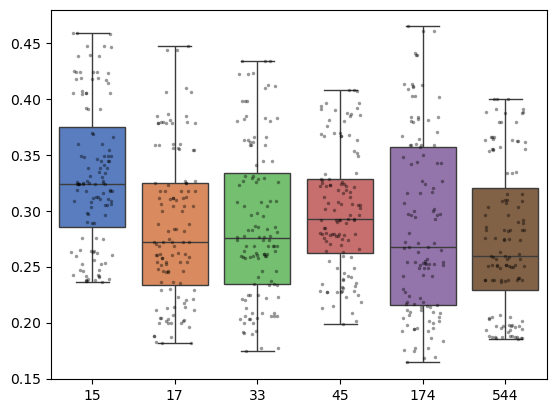

In [33]:
df = pd.DataFrame(missing_stats)

ax = sns.boxplot(
    data=df,
    palette=sns.color_palette("muted"),
    whis=1.5
)

sns.stripplot(
    data=df,
    color="black",
    size=2.5,
    jitter=0.25,   # controlled jitter amount
    alpha=0.4
)

## Missing ratio binning

In [34]:
# general binning
# bin in 5% 

bins = np.arange(0,1,.05)

# dataset binned key order:    dataset: -> metric -> method -> bins ->  list of res "in" bin 
external_metrics_binned = {
    dataset_id:{
        metric:{
            method:{
                bin:[] for bin in bins
                } for method in TESTED_METHODS
            } for metric in external_metrics
        } for dataset_id in cfg['dataset_ids']
}

In [35]:
for cfg, v1 in simulation_results.items():

    dataset_id = cfg[0]
    bin = bins[np.digitize(missing_ratios[cfg], bins, right=True)]

    for method, v2 in v1['external_metrics'].items():
        if method in TESTED_METHODS:
            try:
                for metric, v3 in v2.items():
                    external_metrics_binned[dataset_id][metric][method][bin].append(v3)
            except:
                for metric in external_metrics:                 
                    external_metrics_binned[dataset_id][metric][method][bin].append(np.nan)
                


In [36]:
dataset_ids

[33, 45, 17, 15, 174, 544]

In [37]:
method_ = 'mige_proj'
metric_ = 'ari'

for dataset in dataset_ids:
    print(dataset)
    for bin, values in external_metrics_binned[dataset][metric_][method_].items():
        if len(values) > 0:
            print(f"bin: {bin}, elements: {len(values)}")

33
bin: 0.2, elements: 9
bin: 0.25, elements: 27
bin: 0.30000000000000004, elements: 39
bin: 0.35000000000000003, elements: 18
bin: 0.4, elements: 18
bin: 0.45, elements: 9
45
bin: 0.2, elements: 1
bin: 0.25, elements: 26
bin: 0.30000000000000004, elements: 36
bin: 0.35000000000000003, elements: 31
bin: 0.4, elements: 23
bin: 0.45, elements: 3
17
bin: 0.2, elements: 11
bin: 0.25, elements: 28
bin: 0.30000000000000004, elements: 30
bin: 0.35000000000000003, elements: 24
bin: 0.4, elements: 21
bin: 0.45, elements: 6
15
bin: 0.25, elements: 15
bin: 0.30000000000000004, elements: 21
bin: 0.35000000000000003, elements: 48
bin: 0.4, elements: 9
bin: 0.45, elements: 24
bin: 0.5, elements: 3
174
bin: 0.2, elements: 17
bin: 0.25, elements: 28
bin: 0.30000000000000004, elements: 29
bin: 0.35000000000000003, elements: 15
bin: 0.4, elements: 16
bin: 0.45, elements: 12
bin: 0.5, elements: 3
544
bin: 0.2, elements: 24
bin: 0.25, elements: 21
bin: 0.30000000000000004, elements: 36
bin: 0.350000000000

In [38]:
# Example data

dataset_names = {
    15: "BCW-O",
    17: "BCW-D",
    33: "DERM",
    45: "HD",
    174: "PD",
    544: "OB"
}

method_names = {
    'mige_proj' : 'MIGE',
    'mica': 'MICA',
    'kpod' : 'k-POD',
    'mghm' : 'MGHM',
    'mcnm' : 'MCNM',
    'sc_knn' : 'SC-kNN',
    'sc_mi' : 'SC-MI',
    'km_knn' : 'km-kNN',
    'km_si' : 'km-MI'
}


markers = cycle(['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h'])
linestyles = cycle(['-.',':'])
colors = cycle(sns.color_palette("tab10"))

style_ = {m:{} for m in TESTED_METHODS}
for method in TESTED_METHODS:
    style_[method]['marker'] = next(markers)
    style_[method]['color'] = next(colors)
    if 'mige' in method:
        style_[method]['linestyle'] = '-'
    elif 'cca' in method:
        style_[method]['linestyle'] = '--'
    else:
        style_[method]['linestyle'] = next(linestyles)

style = {method_names.get(k, k): v for k, v in style_.items()}


datasets = dataset_ids
metrics = external_metrics

for dataset, metric in product(datasets, metrics):

    dataset_name = dataset_names[dataset]

    data_ = external_metrics_binned[dataset][metric]

    data = {method_names.get(k, k): v for k, v in data_.items()}


    fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

    for method, ratios in data.items():
        x = []
        y = []
        yerr = []

        for missing_ratio, values in sorted(ratios.items()):
            values = np.asarray(values)
            n = len(values)

            mean = np.mean(values)
            sem = stats.sem(values)
            ci95 = sem * stats.t.ppf(0.975, df=n - 1)

            x.append(missing_ratio)
            y.append(mean)
            yerr.append(ci95)

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker=style[method]["marker"],
            linestyle=style[method]["linestyle"],
            linewidth=1.2,
            markersize=6,
            capsize=3,
            alpha = 0.6,
            label=method
        )

    # Axis labels (use units if applicable)
    ax.set_xlabel("Missing ratio", fontsize=12)
    ax.set_ylabel(""+str.upper(metric), fontsize=12)

    # Ticks
    ax.tick_params(axis="both", labelsize=10)
    ax.set_title(str(dataset_name))

    # Grid: light and unobtrusive
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)
    ax.grid(axis="x", visible=False)

    # Legend
    ax.legend(
        title="Method",
        fontsize=10,
        title_fontsize=11,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    fig.tight_layout()

    # Save for publication
    fig.savefig("../output/figures/missing_ratio/"+dataset_name+str(dataset)+metric+".pdf")
    fig.savefig("../output/figures/missing_ratio/"+dataset_name+str(dataset)+metric+".png")

    plt.close(fig);   # ← hides output


/home/ubuntu/miniconda3/envs/migeclust/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/miniconda3/envs/migeclust/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2027425/2018750894.py:67: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem = stats.sem(values)
/home/ubuntu/miniconda3/envs/migeclust/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/miniconda3/envs/migeclust/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2027425/2018

## MNAR 

In [39]:
# mnar percentage is the fourth elem in the cfg tuple
with open("../config/simulation_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)
mnar_bins = cfg['md_param_grid']['mnar_proportions']

external_metrics_mnar_results = {met:{d: {bin: {m:[] for m in methods} for bin in mnar_bins} for d in cfg['dataset_ids']} for met in external_metrics}
external_metrics_mnar_means = {met:{d: {bin: {m:np.nan for m in methods} for bin in mnar_bins} for d in cfg['dataset_ids']} for met in external_metrics}
external_metrics_mnar_stds = {met:{d: {bin: {m:np.nan for m in methods} for bin in mnar_bins} for d in cfg['dataset_ids']} for met in external_metrics}

for k1,v1 in simulation_results.items():
    # k1 is the cfg 
    mnar_bin = k1[3]
    dataset_id = k1[0]
    # collect results
    for metric in external_metrics:
        for method in methods:
            #res = v1['external_metrics'][method][metric]
            res = safe_get(v1['external_metrics'],method,metric)
            external_metrics_mnar_results[metric][dataset_id][mnar_bin][method].append(res)

# calculate means and standard deviations
for metric,v1 in external_metrics_mnar_results.items():
    for dataset_id, v2 in v1.items():
        for mnar_bin, v3 in v2.items():
            for method,v4 in v3.items():
                external_metrics_mnar_means[metric][dataset_id][mnar_bin][method] = np.mean(v4)
                external_metrics_mnar_stds[metric][dataset_id][mnar_bin][method] = np.std(v4)


In [40]:
df = (
    pd.DataFrame.from_dict(external_metrics_mnar_means['ari'], orient="index")
      .stack()
      .apply(pd.Series)
)

In [41]:
df[TESTED_METHODS].head(20)

mige_proj      mica      kpod      mghm      mcnm    sc_knn  \
33  0.00   0.830300  0.092840  0.013249       NaN       NaN  0.637389   
    0.25   0.828668  0.079411  0.011547       NaN       NaN  0.629847   
    0.50   0.828212  0.082590  0.011406       NaN       NaN  0.633642   
45  0.00   0.115092  0.037532  0.015243       NaN       NaN  0.094067   
    0.25   0.114247  0.050928  0.017667       NaN       NaN  0.085975   
    0.50   0.114886  0.055757  0.016535       NaN       NaN  0.094750   
17  0.00   0.778285  0.484660  0.085584  0.578826  0.572090  0.518525   
    0.25   0.777527  0.483212  0.085282  0.580816  0.571885  0.518675   
    0.50   0.777206  0.483599  0.085282  0.581567  0.572479  0.518675   
15  0.00   0.853395  0.831570  0.533426  0.699637       NaN  0.677526   
    0.25   0.853120  0.829545  0.530342  0.700384       NaN  0.672410   
    0.50   0.856419  0.827915  0.529968  0.698366       NaN  0.671668   
174 0.00   0.150783  0.113953  0.007475       NaN       NaN -0.002348   
    0.25   0.150432  0.113938  0.006219       NaN       NaN -0.007260   
    0.50   0.149467  0.115734  0.006762       NaN       NaN -0.007229   
544 0.00   0.142526  0.240456  0.169947       NaN       NaN  0.193543   
    0.25   0.146172  0.242958  0.168833       NaN       NaN  0.198134   
    0.50   0.143695  0.243556  0.169230       NaN       NaN  0.195352   

             sc_mi    km_knn     km_si  
33  0.00  0.673037  0.079621  0.119128  
    0.25  0.666964  0.078263  0.125718  
    0.50  0.667009  0.083822  0.120534  
45  0.00  0.078327  0.041161  0.054560  
    0.25  0.084153  0.047432  0.058908  
    0.50  0.077491  0.048103  0.057460  
17  0.00  0.576772  0.484294  0.486965  
    0.25  0.574346  0.485057  0.483985  
    0.50  0.573373  0.485057  0.484639  
15  0.00  0.681511  0.817153  0.833334  
    0.25  0.675666  0.816477  0.830216  
    0.50  0.673678  0.815548  0.828969  
174 0.00 -0.035732  0.122320  0.122800  
    0.25 -0.035571  0.126300  0.121253  
    0.50 -0.035711  0.119314  0.117762  
544 0.00  0.140109  0.240342  0.238193  
    0.25  0.135024  0.240457  0.238407  
    0.50  0.134303  0.241974  0.239340